In [9]:

import numpy as np
import matplotlib.pyplot as plt 

from sklearn.metrics.pairwise import euclidean_distances

import scipy.spatial

import timeit

In [10]:
lower_boundary = 0
upper_boundary = 1
n = 2
sample_size = 10_000

np.random.seed(9001) 

X = np.random.uniform( low=lower_boundary, high=upper_boundary, size=(sample_size, n) )
Y = np.random.uniform( low=lower_boundary, high=upper_boundary, size=(sample_size, n) )

print( 'X: ', X )
print( 'Y: ', Y )

X:  [[0.09220363 0.85065196]
 [0.90075012 0.59361319]
 [0.84875299 0.13300259]
 ...
 [0.38171392 0.91366738]
 [0.88293418 0.15839657]
 [0.35563175 0.57334966]]
Y:  [[0.08868318 0.23106393]
 [0.57335982 0.85594149]
 [0.62549367 0.63895098]
 ...
 [0.4393667  0.10427807]
 [0.80477227 0.33535344]
 [0.83223752 0.93260301]]


In [11]:
start = timeit.default_timer()

euclidean_distances_vector_l = []
for i in range(sample_size):
    dist = euclidean_distances( X[i].reshape(1, -1), Y[i].reshape(1, -1) )
    euclidean_distances_vector_l.append( dist[0][0] )
euclidean_distances_vector = np.array( euclidean_distances_vector_l )

stop = timeit.default_timer()
for_time = stop - start
print( 'Running time: ', for_time )

Running time:  1.822333099989919


In [12]:

start = timeit.default_timer()

euclidean_distances_vector_sklearn = []

euclidean_distances_vector_sklearn = euclidean_distances( X, Y, squared=False ).diagonal()

### END CODE HERE ###
stop = timeit.default_timer()
sklearn_time = stop - start
print( 'Running time: ', sklearn_time )

Running time:  0.7654992000025231


In [13]:

start = timeit.default_timer()

euclidean_distances_vector_scipy = []


euclidean_distances_vector_scipy = scipy.spatial.distance.cdist( X, Y, metric='euclidean' ).diagonal()


stop = timeit.default_timer()
scipy_time = stop - start
print( 'Running time: ', scipy_time )

Running time:  0.32831340000848286


In [14]:

start = timeit.default_timer()

euclidean_distances_vector_v = []

euclidean_distances_vector_v = np.sqrt( np.sum( (X - Y) ** 2, axis=1 ) )


### END CODE HERE ###
stop = timeit.default_timer()
np_time = stop - start
print( 'Running time: ', np_time )

Running time:  0.0006117000011727214


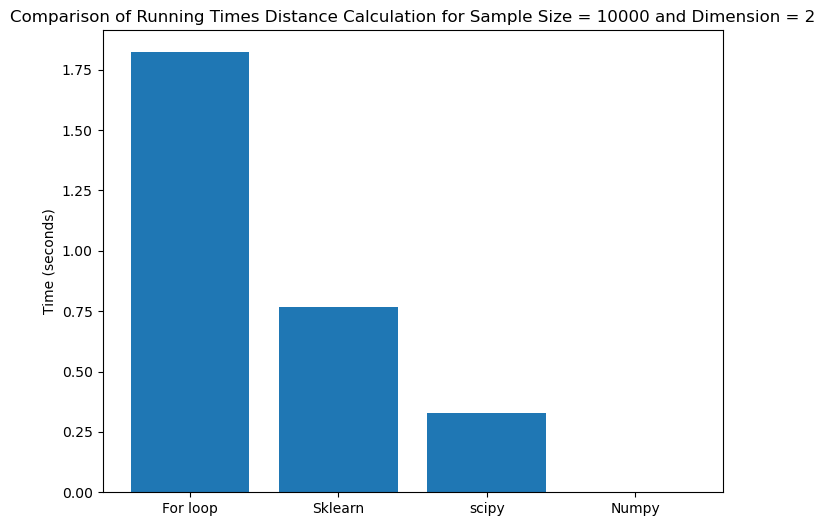

In [15]:

plt.figure(figsize=(8,6))
plt.bar( ['For loop', 'Sklearn', 'scipy', 'Numpy'], [for_time, sklearn_time, scipy_time, np_time] )
plt.ylabel('Time (seconds)')
plt.title('Comparison of Running Times Distance Calculation for Sample Size = %d and Dimension = %d' % (sample_size, n) )
plt.show()

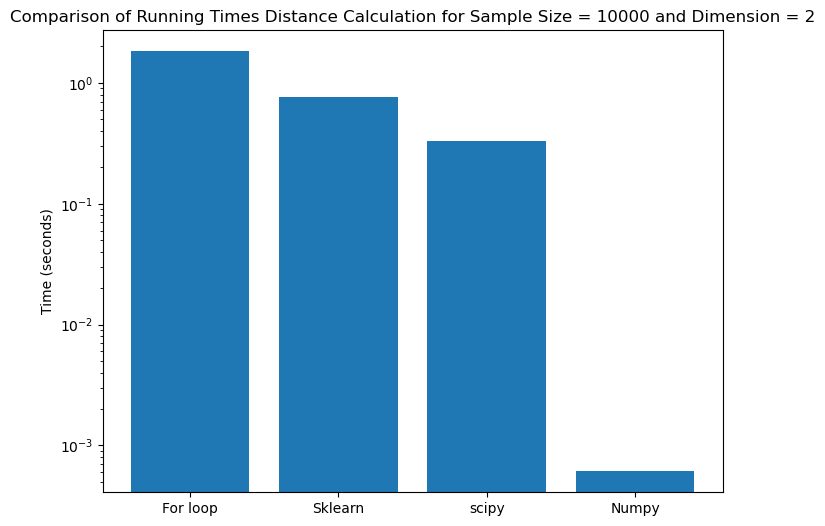

In [16]:

plt.figure(figsize=(8,6))
plt.bar( ['For loop', 'Sklearn', 'scipy', 'Numpy'], [for_time, sklearn_time, scipy_time, np_time] )
plt.yscale('log')
plt.ylabel('Time (seconds)')
plt.title('Comparison of Running Times Distance Calculation for Sample Size = %d and Dimension = %d' % (sample_size, n) )
plt.show()